In [ ]:
!pip install easyocr -q
import os
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import transforms, models
from PIL import Image
from transformers import BertTokenizer, BertForSequenceClassification, AutoModel
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

CSV_PATH = '/content/drive/MyDrive/document_classifier/cache/all_text_dataset.csv'
IMG_DIR = '/content/drive/MyDrive/ColabNotebooks/document-classifier/data/scanned_docs'
MODELS_DIR = '/content/drive/MyDrive/ColabNotebooks/document-classifier/models/trained_models'

cnn_path = os.path.join(MODELS_DIR, 'best_resnet18.pth')
bert_path = os.path.join(MODELS_DIR, 'bert_checkpoint.pth')
fusion_path = os.path.join(MODELS_DIR, 'best_fusion_model.pth')

# Image Transform 
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

print(f"Setup complete. Using device: {device}")

✅ Setup complete. Using device: cuda
📍 CNN Path: best_resnet18.pth
📍 BERT Path: bert_checkpoint.pth
📍 Fusion Path: best_fusion_model.pth


In [ ]:
from sklearn.model_selection import train_test_split

# Load the dataset
if os.path.exists(CSV_PATH):
    df = pd.read_csv(CSV_PATH)
    
    #  Label Encoder for all 10 classes
    le = LabelEncoder()
    df['label_idx'] = le.fit_transform(df['label'])
    class_names = le.classes_
    num_classes = len(class_names)

    #Test Split (20% of the data)
    _, test_df = train_test_split(
        df, 
        test_size=0.2, 
        stratify=df['label'], 
        random_state=42
    )

    print(f"Dataset loaded")
    print(f"Total test samples: {len(test_df)}")

    sample_path = os.path.join(IMG_DIR, test_df.iloc[0]['image_path'])
    print(f"verification - Checking path: {sample_path}")
    if os.path.exists(sample_path):
        print(f"File exists: True")
    else:
        print(f"File exists: False. Check your IMG_DIR or CSV paths.")
else:
    print(f"CSV not found at {CSV_PATH}")

✅ Dataset loaded and Stratified test set created.
📊 Total test samples: 697
🏷️ Unique classes in test set: 10
📝 Classes: ['ADVE' 'Email' 'Form' 'Letter' 'Memo' 'News' 'Note' 'Report' 'Resume'
 'Scientific']

🔍 Verification - Checking path: /content/drive/MyDrive/ColabNotebooks/document-classifier/data/scanned_docs/Email/528954681+-4681.jpg
📂 File exists: True


In [ ]:
if os.path.exists(MODELS_DIR):
    files = os.listdir(MODELS_DIR)
    print(f"Files found in {MODELS_DIR}:")
    for f in files:
        print(f" - {f}")
else:
    print(f"MODELS_DIR folder not found at {MODELS_DIR}")
    parent = os.path.dirname(MODELS_DIR)
    if os.path.exists(parent):
        print(f"\nhecking parent directory ({parent}):")
        print(os.listdir(parent))

📂 Files found in /content/drive/MyDrive/ColabNotebooks/document-classifier/models/trained_models:
 - best_resnet18.pth
 - bert_checkpoint.pth
 - recovered_epoch_1.pth
 - best_fusion_model.pth
 - fusion_checkpoint.pth


In [ ]:
from transformers import AutoModel

# CNN Model (ResNet18)
cnn_model = models.resnet18(weights=None)
cnn_model.fc = nn.Linear(cnn_model.fc.in_features, num_classes)

# BERT Model 
bert_model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased', 
    num_labels=num_classes
)

# 3. Multimodal Fusion Model Architecture 
class MultimodalFusionModel(nn.Module):
    def __init__(self, num_classes, bert_model_name):
        super(MultimodalFusionModel, self).__init__()
        self.resnet = models.resnet18(weights=None)
        self.resnet.fc = nn.Linear(self.resnet.fc.in_features, num_classes) 
        
        self.resnet_features = nn.Sequential(*list(self.resnet.children())[:-1])
        
        self.bert = AutoModel.from_pretrained(bert_model_name)
        
        self.classifier_head = nn.Sequential(
            nn.Linear(512 + 768, 256),
            nn.BatchNorm1d(256), 
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, image, input_ids, attention_mask):
        img_feats = torch.flatten(self.resnet_features(image), 1)
        bert_outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        text_feats = bert_outputs.pooler_output
        combined_feats = torch.cat((img_feats, text_feats), dim=1)
        return self.classifier_head(combined_feats)

fusion_model = MultimodalFusionModel(num_classes=num_classes, bert_model_name='bert-base-uncased')

def load_weights(model, path, name):
    if not os.path.exists(path):
        print(f"{name} weights NOT found at {path}")
        return

    checkpoint = torch.load(path, map_location=device, weights_only=False)
    state_dict = checkpoint['model_state_dict'] if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint else checkpoint
    
    try:
        model.load_state_dict(state_dict)
        print(f"{name} weights loaded successfully.")
    except Exception as e:
        print(f"{name} load error: {e}")
        print(f"try non-strict load for {name}...")
        model.load_state_dict(state_dict, strict=False)
        print(f"{name} weights loaded (non-strict).")

# Load weights
load_weights(cnn_model, cnn_path, "CNN")
load_weights(bert_model, bert_path, "BERT")
load_weights(fusion_model, fusion_path, "Fusion")

# Move to device and set to eval
cnn_model.to(device).eval()
bert_model.to(device).eval()
fusion_model.to(device).eval()

print("\nAll models are in evaluation mode and ready.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ CNN weights loaded successfully.
✅ BERT weights loaded successfully.
✅ Fusion weights loaded successfully.

🚀 All models are in evaluation mode and ready.


In [ ]:
from tqdm.auto import tqdm

# Lists to store results
results = {
    "actual": [],
    "cnn": [],
    "bert": [],
    "fusion": []
}

skipped_files = 0

print(f"🚀 Starting evaluation on {len(test_df)} samples...")

with torch.no_grad():
    for idx, row in tqdm(test_df.iterrows(), total=len(test_df)):
        img_path = os.path.join(IMG_DIR, row['image_path'])
        text_content = str(row['text']) if pd.notna(row['text']) else ""
        actual_idx = row['label_idx']

        if not os.path.exists(img_path):
            skipped_files += 1
            continue
            
        try:
            image = Image.open(img_path).convert('RGB')
            img_tensor = transform(image).unsqueeze(0).to(device)
            
            inputs = tokenizer(
                text_content, 
                return_tensors='pt', 
                padding='max_length', 
                truncation=True, 
                max_length=128
            ).to(device)

            
            
            # CNN Prediction
            cnn_out = cnn_model(img_tensor)
            results["cnn"].append(torch.argmax(cnn_out, dim=1).item())
            
            # BERT Prediction
            bert_out = bert_model(**inputs).logits
            results["bert"].append(torch.argmax(bert_out, dim=1).item())
            
            # Fusion Prediction
            fusion_out = fusion_model(img_tensor, inputs['input_ids'], inputs['attention_mask'])
            results["fusion"].append(torch.argmax(fusion_out, dim=1).item())
            
            # Actual Label
            results["actual"].append(actual_idx)

        except Exception as e:
            print(f"\nError processing index {idx}: {e}")
            continue

print(f"\nEvaluation Complete!")
print(f"Successfully processed: {len(results['actual'])} samples")
if skipped_files > 0:
    print(f"Skipped {skipped_files} missing files.")

🚀 Starting evaluation on 697 samples...


  0%|          | 0/697 [00:00<?, ?it/s]


📊 Evaluation Complete!
Successfully processed: 697 samples


In [ ]:
# 1. Calculate Accuracies
cnn_acc = accuracy_score(results["actual"], results["cnn"])
bert_acc = accuracy_score(results["actual"], results["bert"])
fusion_acc = accuracy_score(results["actual"], results["fusion"])

print("MODEL ACCURACY SUMMARY")
print("-" * 30)
print(f"ResNet (CNN) Accuracy: {cnn_acc:.2%}")
print(f"BERT (Text) Accuracy:   {bert_acc:.2%}")
print(f"Fusion Model Accuracy: {fusion_acc:.2%}")
print("-" * 30)

# Classification Reports
print("\nDETAILED REPORTS")
for model_name in ["cnn", "bert", "fusion"]:
    print(f"\n--- {model_name.upper()} Classification Report ---")
    print(classification_report(
        results["actual"], 
        results[model_name], 
        target_names=class_names,
        digits=4
    ))

📊 MODEL ACCURACY SUMMARY
------------------------------
ResNet (CNN) Accuracy: 44.62%
BERT (Text) Accuracy:   79.63%
Fusion Model Accuracy: 89.24%
------------------------------

📝 DETAILED REPORTS

--- CNN Classification Report ---
              precision    recall  f1-score   support

        ADVE     0.8800    0.9565    0.9167        46
       Email     0.8750    0.6417    0.7404       120
        Form     0.4571    0.7442    0.5664        86
      Letter     0.8571    0.0526    0.0992       114
        Memo     0.7500    0.1210    0.2083       124
        News     0.5789    0.8684    0.6947        38
        Note     0.5882    0.7500    0.6593        40
      Report     0.5000    0.1321    0.2090        53
      Resume     0.1068    0.9167    0.1913        24
  Scientific     0.2031    0.2500    0.2241        52

    accuracy                         0.4462       697
   macro avg     0.5796    0.5433    0.4509       697
weighted avg     0.6609    0.4462    0.4260       697


--- BER

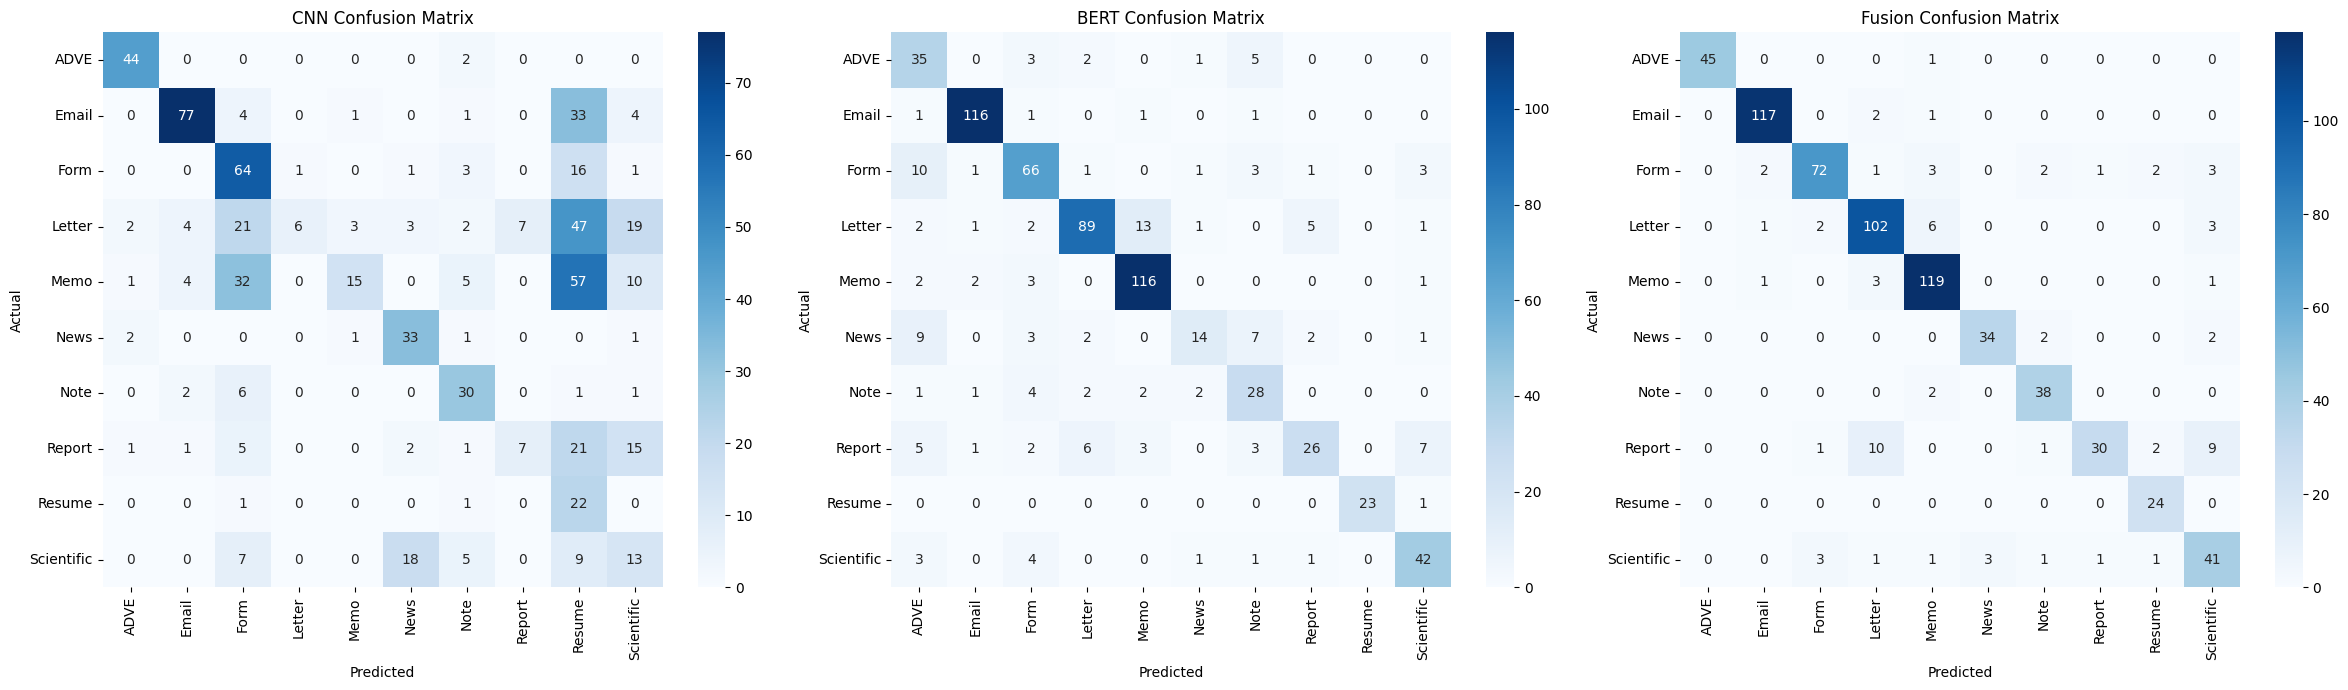

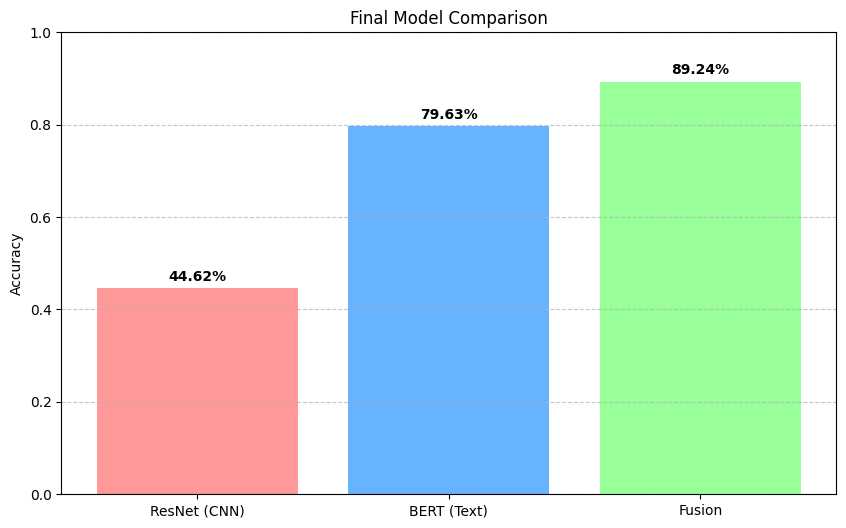

In [ ]:
def plot_confusion_matrix(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=class_names, yticklabels=class_names)
    ax.set_title(title)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')


fig, axes = plt.subplots(1, 3, figsize=(24, 7))

plot_confusion_matrix(results["actual"], results["cnn"], "CNN Confusion Matrix", axes[0])
plot_confusion_matrix(results["actual"], results["bert"], "BERT Confusion Matrix", axes[1])
plot_confusion_matrix(results["actual"], results["fusion"], "Fusion Confusion Matrix", axes[2])

plt.tight_layout()
plt.show()

models_list = ['ResNet (CNN)', 'BERT (Text)', 'Fusion']
accuracies = [cnn_acc, bert_acc, fusion_acc]

plt.figure(figsize=(10, 6))
bars = plt.bar(models_list, accuracies, color=['#ff9999','#66b3ff','#99ff99'])
plt.ylabel('Accuracy')
plt.title('Final Model Comparison')
plt.ylim(0, 1.0)


for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2%}', ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

✅ Visuals saved as 'model_comparison.png' and 'fusion_confusion_matrix.png'


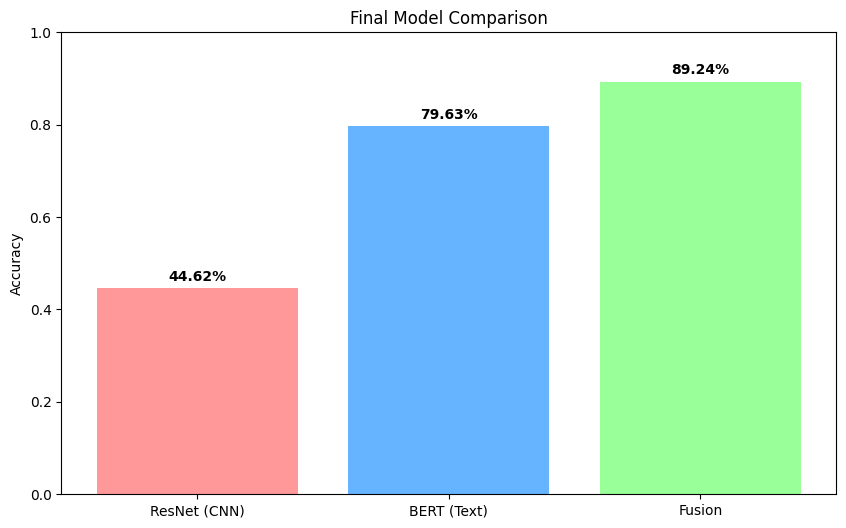

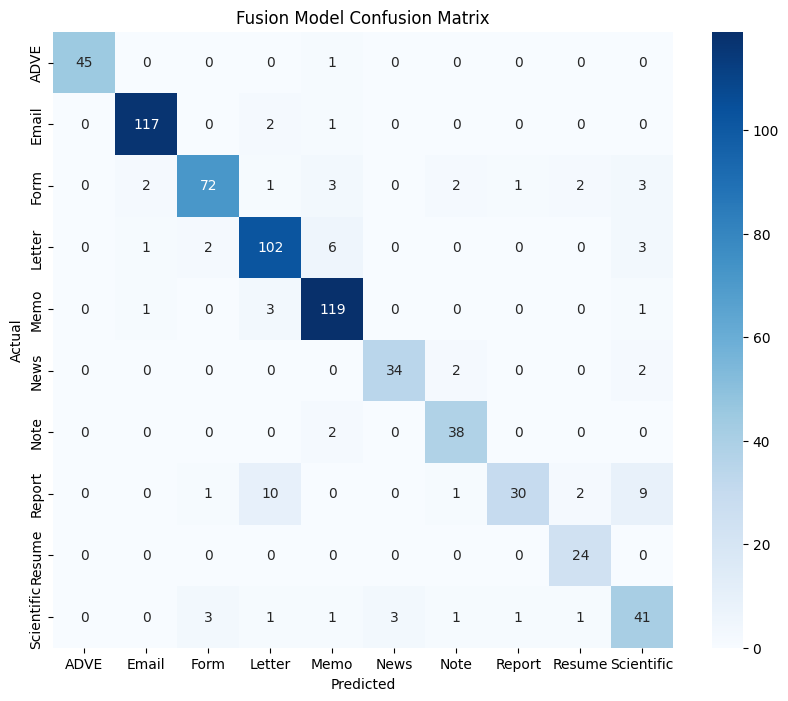

In [ ]:
# Save the comparison bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(['ResNet (CNN)', 'BERT (Text)', 'Fusion'], [cnn_acc, bert_acc, fusion_acc], color=['#ff9999','#66b3ff','#99ff99'])
plt.ylabel('Accuracy')
plt.title('Final Model Comparison')
plt.ylim(0, 1.0)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2%}', ha='center', va='bottom', fontweight='bold')
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')

# Save the Fusion Confusion Matrix specifically
fig, ax = plt.subplots(figsize=(10, 8))
plot_confusion_matrix(results["actual"], results["fusion"], "Fusion Model Confusion Matrix", ax)
plt.savefig('fusion_confusion_matrix.png', dpi=300, bbox_inches='tight')

print("Visuals saved as 'model_comparison.png' and 'fusion_confusion_matrix.png'")